# 순환 신경망
- 모든 입력이 독립적 , 자연어는 순서가 중요 (단어의 순서)
- 이전의 사건이 다음 사건에 영향을 미침
- 자연어 , 주식 , 날씨 , 실시간 센서 데이터
- RNN 기억
- 단점 : 장기 메모리에 약함
- 개선 : LSTM(RNN에 비하여 오래 기억하지만 그래도 희석됨)
- 트랜스포머 : 집중해야할 것 , 기억해야할 중요내용만 저장(어텐션 기법) , 마스킹


$h_t$

$t$

In [70]:
from nltk.corpus import movie_reviews
reviews = [movie_reviews.raw(fileid) for fileid in movie_reviews.fileids()]
categories = [movie_reviews.categories(fileid)[0] for fileid in movie_reviews.fileids()]

In [71]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
np.random.seed(42)
tf.random.set_seed(42)

In [72]:
max_words = 10000
tokenizer = Tokenizer(num_words=max_words , oov_token="UNK")
tokenizer.fit_on_texts(reviews)
tokenizer.fit_on_sequences(reviews)
x = tokenizer.texts_to_sequences(reviews)
len(x[0]) , len(x[1])

(710, 240)

In [73]:
# 학습을 위해서는 모든 문장의 길이가 같아야한다.
from tensorflow.keras.preprocessing.sequence import pad_sequences
maxlen = 500
x = pad_sequences(x, maxlen=maxlen , truncating='pre') # 앞을 자름


In [74]:
len(x[0]), len(x[1]) , x[0][:10]
x.shape

(2000, 500)

In [75]:
label_dict = {'pos' : 1 , 'neg' : 0}
y = np.array([label_dict[c] for c in categories])
y[:10]
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=400, random_state=42)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding , Flatten , Dense

model = Sequential([
    Embedding(max_words , 32 , input_length=maxlen),
    Flatten(),
    Dense(1 , activation='sigmoid') # 확률 분포

])
model.compile(optimizer='adam' , loss='binary_crossentropy' , metrics=['acc'])
history = model.fit(x_train , y_train , epochs=10 , batch_size=32 , validation_split=0.2)

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - acc: 0.4953 - loss: 0.6937 - val_acc: 0.5219 - val_loss: 0.6986
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - acc: 0.9508 - loss: 0.5876 - val_acc: 0.5719 - val_loss: 0.6915
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - acc: 0.9828 - loss: 0.4389 - val_acc: 0.5594 - val_loss: 0.6829
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - acc: 0.9969 - loss: 0.2591 - val_acc: 0.5750 - val_loss: 0.6700
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - acc: 0.9984 - loss: 0.1334 - val_acc: 0.5875 - val_loss: 0.6599
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - acc: 0.9992 - loss: 0.0723 - val_acc: 0.5844 - val_loss: 0.6550
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - acc: 1.0000 - loss: 0.0438 - val_acc: 0.5938 - val_loss: 0.6531
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - acc: 1.0000 - loss: 0.0292 - val_acc: 0.5938 - val_loss: 0.6519
Epoch 9/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - acc: 1.0000 - loss: 

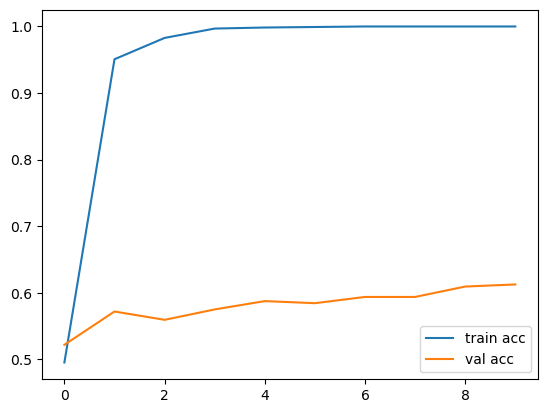

In [76]:
import matplotlib.pyplot as plt
plt.plot(history.history['acc'] , label='train acc')
plt.plot(history.history['val_acc'] , label='val acc')
plt.legend()
plt.show()

In [77]:
model.evaluate(x_test , y_test)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.6525 - loss: 0.6367 


[0.6366614699363708, 0.6524999737739563]

In [78]:
from tensorflow.keras.layers import SimpleRNN , Dropout

model = Sequential([
    Embedding(max_words , 32 , input_length=maxlen),
    SimpleRNN(32), # RNN 레이어
    Dropout(0.5), # 과적합 방지
    Dense(1 , activation='sigmoid') # 확률 분포

])

model.compile(optimizer='adam' , loss='binary_crossentropy' , metrics=['acc'])
history = model.fit(x_train , y_train , epochs=10 , batch_size=32 , validation_split=0.2)
model.evaluate(x_test , y_test)

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - acc: 0.5000 - loss: 0.7059 - val_acc: 0.4500 - val_loss: 0.7078
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - acc: 0.6680 - loss: 0.6392 - val_acc: 0.4844 - val_loss: 0.6968
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - acc: 0.8094 - loss: 0.5630 - val_acc: 0.5375 - val_loss: 0.6932
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - acc: 0.9305 - loss: 0.3792 - val_acc: 0.5281 - val_loss: 0.7282
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - acc: 0.9766 - loss: 0.2352 - val_acc: 0.6000 - val_loss: 0.7195
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - acc: 0.9891 - loss: 0.1531 - val_acc: 0.5656 - val_loss: 0.7834
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - acc: 0.9977 - loss: 0.0930 - val_acc: 0.5125 - val_loss: 0.8829
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - acc: 0.9961 - loss: 0.0626 - val_acc: 0.5188 - val_loss: 0.9076
Epoch 9/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - acc: 0.9984

[1.059421420097351, 0.48750001192092896]

In [79]:
tmp = Embedding(max_words , 32 , input_length=maxlen)(x_train)
SimpleRNN(32)(tmp)

<tf.Tensor: shape=(1600, 32), dtype=float32, numpy=
array([[-0.18740405,  0.06341576, -0.08017638, ..., -0.08525436,
        -0.03486107,  0.09167726],
       [-0.0477032 ,  0.11292972, -0.01846451, ...,  0.0343268 ,
         0.01521886, -0.03837646],
       [ 0.08004836, -0.16156918,  0.00344814, ..., -0.18073583,
        -0.11478546,  0.18052012],
       ...,
       [ 0.07163413, -0.16063182, -0.09048901, ..., -0.1510393 ,
         0.04717017, -0.12147363],
       [ 0.18126749,  0.1353525 ,  0.28489348, ...,  0.03750971,
         0.18434988, -0.02581538],
       [ 0.41138685, -0.1295222 ,  0.09090391, ...,  0.08210367,
         0.20916744,  0.05325404]], dtype=float32)>